IA & Data science (LU3IN0226) -- 2025-2026
--------
*&copy; Equipe pédagogique: Christophe Marsala, Olivier Schwander, Jean-Noël Vittaut, Maxellende Julienne.*


# Projet final

<font size="+1" color="RED">**[Q]**</font> **Indiquer dans la boîte ci-dessous vos noms et prénoms :**

*Double-cliquer ici et insérer les noms et prénoms de votre binôme*

Ce projet peut être fait en binôme ou tout seul.

**Le nom de chaque membre du binôme doit être indiqué dans la boîte ci-dessus**.


**Le compte-rendu est soumis sur la page Moodle.

Si vous êtes en binôme : **<u>un seul rendu doit être remis sur un seul des deux comptes du binôme</u>**.

Les groupes de plus de 2 personnes ne sont pas autorisés.

**La dernière séance de TD-TME11 de votre groupe sera réservée pour travailler sur ce mini-projet.**

<font color="RED" size="+1"><b>[Q]</b></font> **Renommer ce notebook**

**Nom à donner au fichier à poster** : *projet-Nom1_Nom2.ipynb* 
- *Nom1* et *Nom2* : noms des membres du binôme

Voir ci-dessous ce qui est à remettre.



# Projet - mai 2026

<b>Date de remise du compte-rendu : <font size="+1" color="RED">au plus tard le lundi 1er juin 2026, avant 10h</font></b>.
    
<b>Attention!</b> le site Moodle ferme à 20h pile (heure du site Moodle)! prévoyez de vous y connecter au moins 15mn avant la fermeture...
<b>Il n'y aura pas de prolongation possible.</b>

## Travail à faire

Vous devez compléter ce notebook en rajoutant vos expérimentations avec vos algorithmes d'apprentissage (supervisé et non-supervisé) sur les données Fashion MNIST fournies (voir plus loin).

Vous devez appliquer les algorithmes d'apprentissage vus en cours et réaliser une analyse sur les données afin de mettre en évidence des résultats intéressants.

Les données seront chargées par les commandes de chargement des données fournies dans ce notebook (ci-dessous).
Dans le notebook que vous rendrez, le chargement des fichiers de données doit considérer cette arborescence.


## Remarque: utilisation d'IA générative 

Toute utilisation d'une IA générative (ChatGPT, Mistral, Claude,...) pour réaliser certains traitements de ce projet doit **obligatoirement** être indiqué dans votre notebook. De plus, si vous utilisez une telle IA générative, vous devez pouvoir être capable d'expliquer ce qu'elle vous a fourni et que vous avez utilisé.

## Compte-rendu demandé
Ce qui doit être remis avant la date limite : un unique fichier archive compressé (`.tgz`, ou `.zip` uniquement) de nom :
`projet-Nom1_Nom2.tgz` ou `projet-Nom1_Nom2.zip` contenant:
- ce **notebook** complété (et avec vos noms !). Il doit pouvoir être exécuté sans autre apport (pensez à vous en assurer avant de le rendre). 
- votre **librairie iads** complète, c'est à dire votre répertoire `iads/` contenant tous les fichiers python complets.
- un **poster** sous la forme d'un fichier PDF dont le nom est de la forme: *tme11-Nom1_Nom2.pdf* qui correspond à un poster décrivant l'ensemble des expérimentations menées et les résultats obtenus.


**Très important** : les fichiers dans l'archive doivent être placés de façon à respecter la structure de fichiers suivante :

          --projet-Nom1_Nom2/
              --iads/
                  -- Classifiers.py
                  -- etc.
              -- Projet/
                  --  projet-Nom1_Nom2.ipynb


<b>Remarque</b>: 
- **Les <u>fichiers de données ne doivent pas être inclus dans votre archive</u>** ! 
- Pensez à vérifier que votre archive contient bien tous les fichiers demandés et **seulement** les fichiers demandés.
- **Tous les fichiers demandés doivent être soumis avant la date limite**, en une seule archive comme indiqué ci-dessus.

## Soutenance des projets
**Les soutenances auront lieu le <font size="+1" color="RED">mardi 2 juin 2026</font>, à partir de 14h**. 

Un ordre de passage ainsi que la salle de TME où elles auront lieu seront affichées sur le Moodle la veille (la remise d'un compte-rendu à la date d'échéance indiquée (avant le lundi 1er juin 2026, 10h) est **obligatoire** pour passer une soutenance).

La <b>soutenance est obligatoire</b> : <u>tout projet pour lequel la soutenance n'est pas passée sera noté $0$</u>.

Modalités de la soutenance:
- durée de la soutenance : 10 mn pour un binôme, 7 mn pour un monôme ;
- elle a lieu devant un ordinateur avec le notebook et le poster comme support ;
    - elle commence par une rapide présentation des expérimentations réalisées et résultats obtenus (max. 4 à 5mns)
    - puis elle se poursuit par des questions posées individuellement aux membres du binômes sur les expériences ou le code python réalisé.
- la note de soutenance est individuelle pour chaque membre d'un binôme.



In [23]:
# - - - - - - - - - - - - - - - - - -
# imports utiles
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mtpl
from sklearn.model_selection import KFold
%matplotlib inline  
#mtpl.use("Agg")

import math
import time
import sys

# pour les dendrogrammes) :
import scipy

# --------------------------------
# Les instructions suivantes sont utiles pour recharger automatiquement 
# le code modifié dans les librairies externes
%load_ext autoreload
%autoreload 2
# --------------------------------


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
# Importation de votre librairie iads:
# La ligne suivante permet de préciser le chemin d'accès à la librairie iads
#sys.path.append("C:\\Users\\benhm\\Downloads\\LU3IN026")   # iads doit être dans le répertoire père du répertoire courant !
sys.path.append("../")
# Importation de la librairie iads
import iads as iads

# importation de Classifiers
from iads import Classifiers as cl

# importation de utils
from iads import utils as ut

# importation de evaluation
from iads import evaluation as ev

# importation de Clustering 
from iads import Clustering as clust


## Données pour le projet : Fashion MNIST

Les données sont fournies dans l'archive `data.tgz`. 
Cette archive contient 2 fichiers CSV:
- le fichier `fashion-mnist_train.csv`: ce fichier doit servir à l'entraînement de vos modèles, et leur évaluation en validation croisée,
- le fichier `fashion-mnist_test.csv`: ce fichier ne doit être utilisé que pour évaluer un modèle et il ne doit pas servir pour faire mettre au point le modèle.


Une documentation sur ces données peut être consultée sur la <a href="https://fr.wikipedia.org/wiki/Fashion_MNIST" target="NEW">page wikipedia Fashion MNIST</a>.


#### Chargement des données

In [25]:
#data_train = pd.read_csv("../data/fashion-mnist_train.csv")
data_train = pd.read_csv("C:\\Users\\benhm\\Downloads\\LU3IN026\\data\\fashion-mnist_train.csv")

In [26]:
data_train

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,1,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,8,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [27]:
#data_test = pd.read_csv("C:\\Users\\benhm\\Downloads\\LU3IN026\\data\\fashion-mnist_test.csv")
data_test = pd.read_csv("../data/fashion-mnist_test.csv")

In [28]:
data_test

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,0,0,0,0,0,0,0,0,0,...,32,23,14,20,0,0,1,0,0,0
9996,6,0,0,0,0,0,0,0,0,0,...,0,0,0,2,52,23,28,0,0,0
9997,8,0,0,0,0,0,0,0,0,0,...,175,172,172,182,199,222,42,0,1,0
9998,8,0,1,3,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [29]:
data_train.shape #60000 images d’entraînement

(60000, 785)

In [30]:
data_test.shape #10000 images de test

(10000, 785)

## Tâches à réaliser

### Apprentissage supervisé

*Tâches*: évaluation d'algorithmes et de représentations des données.
- classification binaire
- classification multi-classe

*Etudes suggérées*:
- différents classifiers:
    - perceptron et variantes
    - k-plus proches voisins 
    - arbres de décision
    - ensembles de classifieurs
- analyse des résultats: comparaison des approches et de leurs hyper-paramètres
    - accuracy, temps d'exécutions
    - score fold par fold
    - matrice de confusion
    - ...


### Apprentissage non-supervisé

*Tâche*: présence éventuelle de groupes de données: groupes intra-classes, et/ou groupes interclasses.

*Etudes possibles*:
- étudier l'application d'un clustering hiérarchique et son résultat;
- étudier les résultats de l'application de l'algorithme des k-moyennes, pour différentes valeurs de k: roposer des évaluations des clusters trouvés afin de mettre en évidence les plus intéressants:
    - en utilisant les indices d'évaluation présentés en cours;
    - en comparant par diverses méthodes les clusters trouvés avec les vrais labels des classes (targets y).
- proposer une visualisation des résultats obtenus
- analyse des exemples mal-classés: est-ce qu'ils forment un (ou des) sous-groupes?
- ...


   


## Poster à rendre dans le compte-rendu (format PDF)

Votre poster doit décrire de façon synthétique **l'ensemble des expérimentations** menées sur les données, les résultats obtenus en apprentissage supervisé et en apprentissage non-supervisé ainsi que les conclusions/bilans que vous tirez de ces expérimentations (ie. ce que vous avez appris sur ces données).

**Important*: vous devez indiquer vos noms/prénoms sur le poster.


# 
Votre travail commence à partir d'ici 

In [31]:
# Séparer X / y
X_train = data_train.drop("label", axis=1).values  #les données
y_train = data_train["label"].values               #les labels 

X_test = data_test.drop("label", axis=1).values
y_test = data_test["label"].values

# NORMALISATION : on transforme les pixels pour qu’ils soient entre 0 et 1 au lieu de 0 à 255
X_train = X_train / 255.0
X_test = X_test / 255.0

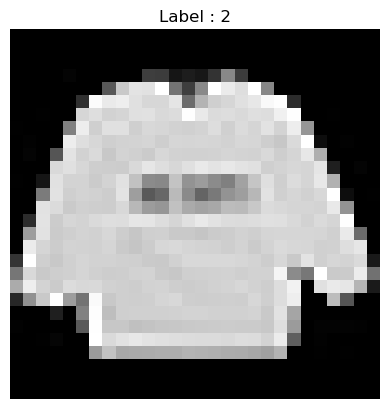

In [32]:
image = X_train[0].reshape(28, 28)
#On fait reshape(28, 28) parce que les images MNIST sont stockées aplatis dans un vecteur, mais imshow() a besoin d’une matrice 2D pour afficher une image.
plt.imshow(image, cmap="gray")
plt.title(f"Label : {y_train[0]}")
plt.axis("off") #cacher les axes autour de l’image

plt.show()

In [33]:
# Afin de réduire les temps de calcul liés à l’algorithme KNN,
# nous réalisons les expérimentations sur un sous-ensemble du dataset.
# En effet, KNN nécessite de calculer la distance entre chaque image
# et toutes les images d’apprentissage, ce qui devient très coûteux
# sur l’ensemble complet de Fashion-MNIST.

# Classe 0 vs reste
y_train_bin = np.where(y_train == 0, 1, -1)
y_test_bin = np.where(y_test == 0, 1, -1)

# SOUS-ENSEMBLE DES DONNEES
X_small = X_train[:500]
y_small = y_train_bin[:500]


Nous commençons par une étude en apprentissage supervisé sur le dataset Fashion-MNIST.
Dans un premier temps, nous évaluons plusieurs modèles de classification binaire afin de distinguer une classe donnée du reste des images.
Nous comparons notamment les performances du K-plus proches voisins (KNN), du perceptron et des arbres de décision en faisant varier certains hyperparamètres (comme k pour KNN ou ϵ pour les arbres).
Pour chaque modèle, nous mesurons l’accuracy, les scores obtenus lors de la validation croisée fold par fold, la moyenne et l’écart-type des performances, ainsi que les temps d’exécution.


===== k = 1 =====
Performances     : [0.9397590361445783, 0.9578313253012049, 0.9166666666666666]
Accuracy moyenne : 0.9381
Ecart-type       : 0.0168
Temps            : 1.89 s

===== k = 3 =====
Performances     : [0.9457831325301205, 0.9457831325301205, 0.9404761904761905]
Accuracy moyenne : 0.9440
Ecart-type       : 0.0025
Temps            : 1.88 s

===== k = 5 =====
Performances     : [0.8975903614457831, 0.9578313253012049, 0.9583333333333334]
Accuracy moyenne : 0.9379
Ecart-type       : 0.0285
Temps            : 1.81 s

===== k = 7 =====
Performances     : [0.9457831325301205, 0.9397590361445783, 0.9583333333333334]
Accuracy moyenne : 0.9480
Ecart-type       : 0.0077
Temps            : 1.78 s

===== k = 9 =====
Performances     : [0.9337349397590361, 0.9337349397590361, 0.9702380952380952]
Accuracy moyenne : 0.9459
Ecart-type       : 0.0172
Temps            : 1.81 s

MEILLEUR MODELE
Meilleur k : 7
Accuracy   : 0.9480


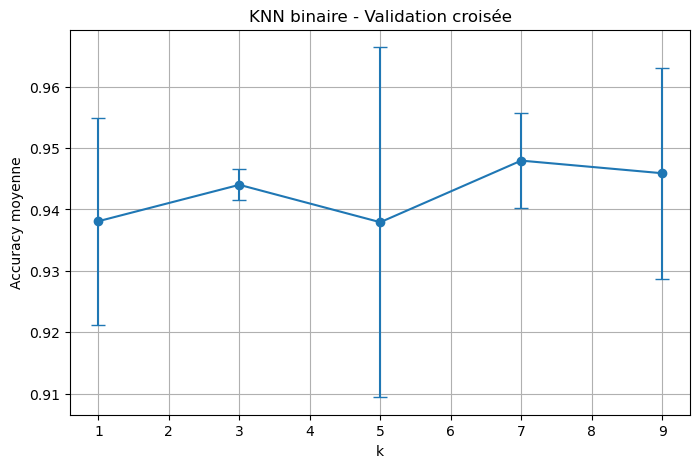

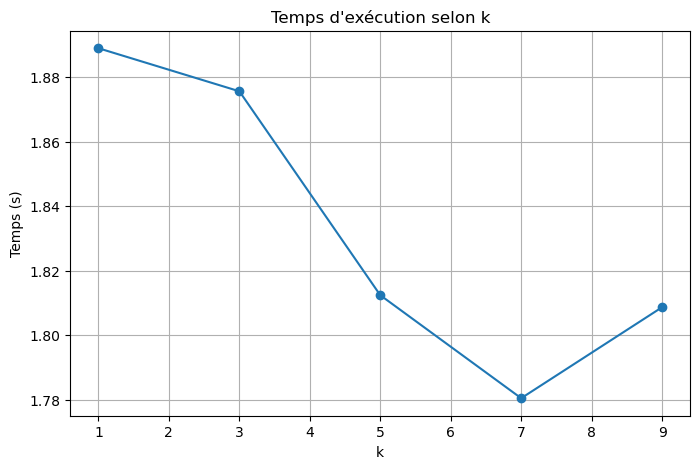

In [34]:
# KNN BINAIRE


# Classe 0 vs reste
y_train_bin = np.where(y_train == 0, 1, -1)
y_test_bin = np.where(y_test == 0, 1, -1)




k_values = [1, 3, 5, 7, 9]

mean_scores = []
std_scores = []
times = []

for k in k_values:

    print(f"\n===== k = {k} =====")

    knn = cl.ClassifierKNN(X_small.shape[1], k)

    start = time.time()

    # Validation croisée 
    perf, _, _ = ev.validation_croisee(
        knn,
        (X_small, y_small),
        nb_iter=3
    )

    exec_time = time.time() - start

    # Statistiques
    perf_moy, perf_std = ev.analyse_perfs(perf)

    mean_scores.append(perf_moy)
    std_scores.append(perf_std)
    times.append(exec_time)

    print(f"Performances     : {perf}")
    print(f"Accuracy moyenne : {perf_moy:.4f}")
    print(f"Ecart-type       : {perf_std:.4f}")
    print(f"Temps            : {exec_time:.2f} s")


# Meilleur k
best_index = np.argmax(mean_scores)

print("\n==============================")
print("MEILLEUR MODELE")
print("==============================")
print(f"Meilleur k : {k_values[best_index]}")
print(f"Accuracy   : {mean_scores[best_index]:.4f}")


# Accuracy selon k

plt.figure(figsize=(8,5))
plt.errorbar(
    k_values,
    mean_scores,
    yerr=std_scores,
    marker='o',
    capsize=5
)

plt.xlabel("k")
plt.ylabel("Accuracy moyenne")
plt.title("KNN binaire - Validation croisée")
plt.grid(True)
plt.show()


# Temps selon k

plt.figure(figsize=(8,5))
plt.plot(k_values, times, marker='o')

plt.xlabel("k")
plt.ylabel("Temps (s)")
plt.title("Temps d'exécution selon k")
plt.grid(True)
plt.show()



PERCEPTRON
Accuracy train      : 0.9788
Accuracy test       : 0.9522
Accuracy CV moyenne : 0.9486
Ecart-type CV       : 0.0013
Temps apprentissage : 3.85 s


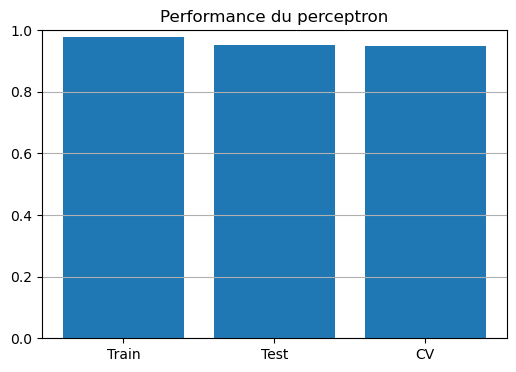

In [35]:
# PERCEPTRON

# Sous-ensemble pour accélérer l'apprentissage
X_small = X_train[:5000]
y_small = y_train_bin[:5000]

# Création du classifieur
perceptron = cl.ClassifierPerceptron(
    input_dimension=X_small.shape[1],
    learning_rate=0.01
)

# APPRENTISSAGE
start = time.time()

perceptron.train(
    X_small,
    y_small,
    nb_max=20
)

temps_apprentissage = time.time() - start

# EVALUATION
acc_train = perceptron.accuracy(X_small, y_small)
acc_test = perceptron.accuracy(X_test, y_test_bin)

# Validation croisée
perf, perf_moy, perf_std = ev.validation_croisee(
    perceptron,
    (X_small, y_small),
    nb_iter=3
)

# analyse_perfs 
perf_moy, perf_std = ev.analyse_perfs(perf)

# AFFICHAGE
print("================================")
print("PERCEPTRON")
print("================================")

print(f"Accuracy train      : {acc_train:.4f}")
print(f"Accuracy test       : {acc_test:.4f}")
print(f"Accuracy CV moyenne : {perf_moy:.4f}")
print(f"Ecart-type CV       : {perf_std:.4f}")
print(f"Temps apprentissage : {temps_apprentissage:.2f} s")

# VISUALISATION
plt.figure(figsize=(6,4))

plt.bar(
    ["Train", "Test", "CV"],
    [acc_train, acc_test, perf_moy]
)

plt.ylim(0, 1)
plt.title("Performance du perceptron")
plt.grid(axis="y")

plt.show()


===== k = 1 =====
Performances     : [0.6748466257668712, 0.6993865030674846, 0.735632183908046]
Accuracy moyenne : 0.7033
Ecart-type       : 0.0250
Temps            : 17.92 s

===== k = 3 =====
Performances     : [0.6809815950920245, 0.7055214723926381, 0.6954022988505747]
Accuracy moyenne : 0.6940
Ecart-type       : 0.0101
Temps            : 17.51 s

===== k = 5 =====
Performances     : [0.6809815950920245, 0.6687116564417178, 0.6954022988505747]
Accuracy moyenne : 0.6817
Ecart-type       : 0.0109
Temps            : 17.14 s

===== k = 7 =====
Performances     : [0.7300613496932515, 0.6687116564417178, 0.6839080459770115]
Accuracy moyenne : 0.6942
Ecart-type       : 0.0261
Temps            : 17.20 s

===== k = 9 =====
Performances     : [0.6932515337423313, 0.6748466257668712, 0.764367816091954]
Accuracy moyenne : 0.7108
Ecart-type       : 0.0386
Temps            : 17.32 s

MEILLEUR MODELE
Meilleur k : 9
Accuracy CV : 0.7108
Accuracy test : 0.7133


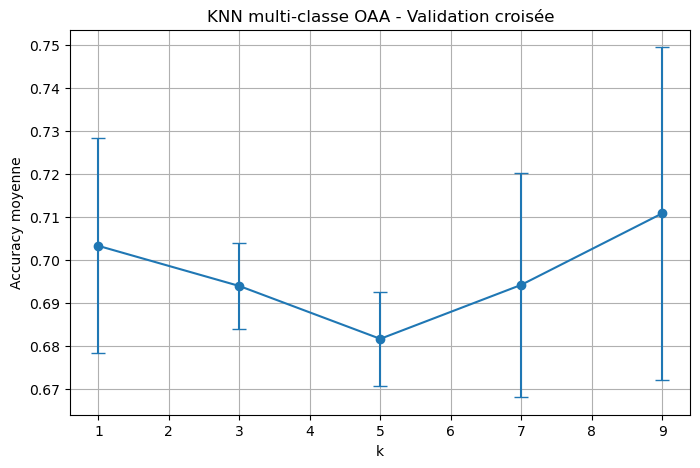

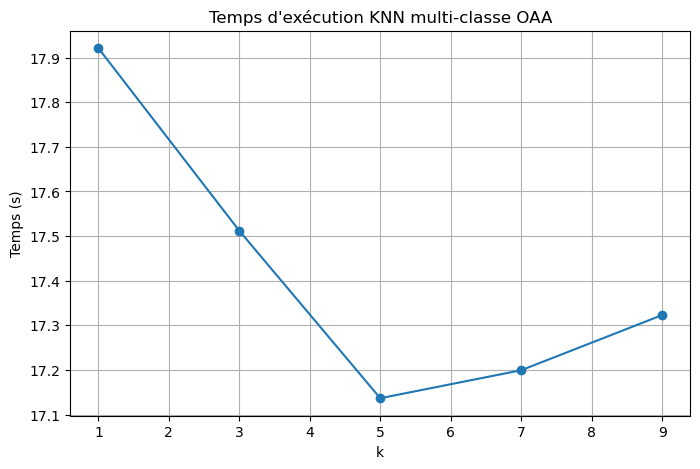

In [38]:
# KNN MULTI-CLASSE avec One-Against-All

# IMPORTANT : ClassifierKNN est un classifieur binaire (-1 / +1).
# Pour Fashion-MNIST (classes 0 à 9), on l'encapsule donc dans
# ClassifierMultiOAA, qui entraîne un KNN binaire par classe.

# Sous-ensemble pour accélérer les calculs
X_small = X_train[:500]
y_small = y_train[:500]

k_values = [1, 3, 5, 7, 9]

mean_scores = []
std_scores = []
times = []

for k in k_values:

    print(f"\n===== k = {k} =====")

    # Classifieur binaire de base
    knn_bin = cl.ClassifierKNN(X_small.shape[1], k)

    # Passage en multi-classe : One-Against-All
    knn_oaa = cl.ClassifierMultiOAA(knn_bin)

    start = time.time()

    # Validation croisée stratifiée sur les labels 0..9
    perf, _, _ = ev.validation_croisee(
        knn_oaa,
        (X_small, y_small),
        nb_iter=3
    )

    exec_time = time.time() - start

    # Statistiques
    perf_moy, perf_std = ev.analyse_perfs(perf)

    mean_scores.append(perf_moy)
    std_scores.append(perf_std)
    times.append(exec_time)

    print(f"Performances     : {perf}")
    print(f"Accuracy moyenne : {perf_moy:.4f}")
    print(f"Ecart-type       : {perf_std:.4f}")
    print(f"Temps            : {exec_time:.2f} s")


# Meilleur k
best_index = np.argmax(mean_scores)
best_k = k_values[best_index]

print("\n==============================")
print("MEILLEUR MODELE")
print("==============================")
print(f"Meilleur k : {best_k}")
print(f"Accuracy CV : {mean_scores[best_index]:.4f}")


# Entraînement final du meilleur modèle
best_knn_bin = cl.ClassifierKNN(X_small.shape[1], best_k)
best_knn_oaa = cl.ClassifierMultiOAA(best_knn_bin)
best_knn_oaa.train(X_small, y_small)

# Le test complet peut être lent avec OAA + KNN.
# Pour tester plus vite, remplacer X_test/y_test par X_test[:1000]/y_test[:1000].
acc_test = best_knn_oaa.accuracy(X_test, y_test)

print(f"Accuracy test : {acc_test:.4f}")


# Accuracy selon k
plt.figure(figsize=(8,5))
plt.errorbar(
    k_values,
    mean_scores,
    yerr=std_scores,
    marker='o',
    capsize=5
)

plt.xlabel("k")
plt.ylabel("Accuracy moyenne")
plt.title("KNN multi-classe OAA - Validation croisée")
plt.grid(True)
plt.show()


# Temps selon k
plt.figure(figsize=(8,5))
plt.plot(k_values, times, marker='o')

plt.xlabel("k")
plt.ylabel("Temps (s)")
plt.title("Temps d'exécution KNN multi-classe OAA")
plt.grid(True)
plt.show()



===== alpha = 0.1 =====
Performances     : [0.5766871165644172, 0.6196319018404908, 0.7068965517241379]
Accuracy moyenne : 0.6344
Ecart-type       : 0.0542
Temps            : 0.23 s

===== alpha = 0.5 =====
Performances     : [0.6134969325153374, 0.6012269938650306, 0.6666666666666666]
Accuracy moyenne : 0.6271
Ecart-type       : 0.0284
Temps            : 0.22 s

===== alpha = 1.0 =====
Performances     : [0.656441717791411, 0.6012269938650306, 0.632183908045977]
Accuracy moyenne : 0.6300
Ecart-type       : 0.0226
Temps            : 0.30 s

MEILLEUR MODELE
Alpha optimal : 0.1
Accuracy CV   : 0.6344
Accuracy test : 0.6650


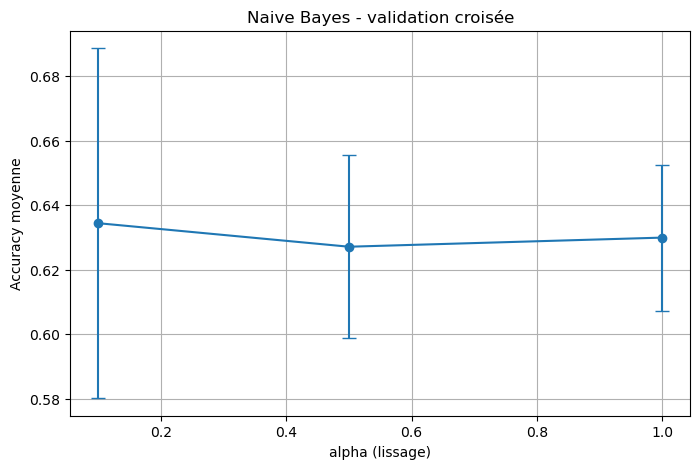

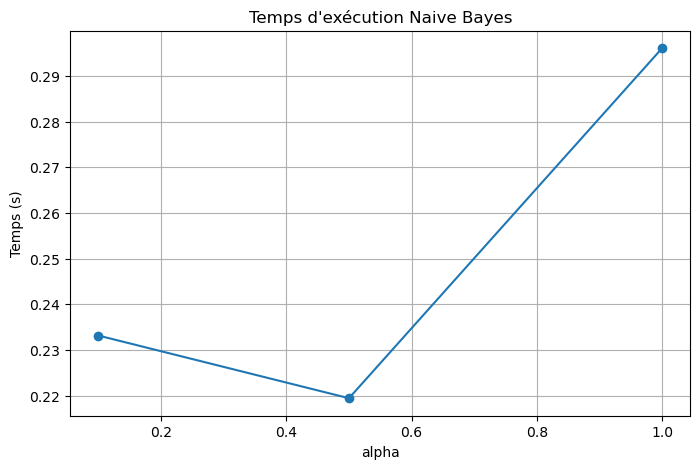

In [37]:
# =========================
# NAIVE BAYES MULTICLASSE
# =========================

X_small = X_train[:500]
y_small = y_train[:500]

alphas = [0.1, 0.5, 1.0]  # paramètre de lissage (Laplace)

mean_scores = []
std_scores = []
times = []

for alpha in alphas:

    print(f"\n===== alpha = {alpha} =====")

    nb = cl.ClassifierNaiveBayes(
        input_dimension=X_small.shape[1],
        alpha=alpha
    )

    start = time.time()

    perf, _, _ = ev.validation_croisee(
        nb,
        (X_small, y_small),
        nb_iter=3
    )

    exec_time = time.time() - start

    perf_moy, perf_std = ev.analyse_perfs(perf)

    mean_scores.append(perf_moy)
    std_scores.append(perf_std)
    times.append(exec_time)

    print(f"Performances     : {perf}")
    print(f"Accuracy moyenne : {perf_moy:.4f}")
    print(f"Ecart-type       : {perf_std:.4f}")
    print(f"Temps            : {exec_time:.2f} s")


# =========================
# MEILLEUR MODELE
# =========================

best_idx = np.argmax(mean_scores)

print("\n==============================")
print("MEILLEUR MODELE")
print("==============================")
print(f"Alpha optimal : {alphas[best_idx]}")
print(f"Accuracy CV   : {mean_scores[best_idx]:.4f}")


# =========================
# TEST FINAL
# =========================

best_nb = cl.ClassifierNaiveBayes(
    input_dimension=X_small.shape[1],
    alpha=alphas[best_idx]
)

best_nb.train(X_small, y_small)

acc_test = best_nb.accuracy(X_test, y_test)

print(f"Accuracy test : {acc_test:.4f}")


# =========================
# COURBES
# =========================

plt.figure(figsize=(8,5))
plt.errorbar(
    alphas,
    mean_scores,
    yerr=std_scores,
    marker='o',
    capsize=5
)
plt.xlabel("alpha (lissage)")
plt.ylabel("Accuracy moyenne")
plt.title("Naive Bayes - validation croisée")
plt.grid(True)
plt.show()


plt.figure(figsize=(8,5))
plt.plot(alphas, times, marker='o')
plt.xlabel("alpha")
plt.ylabel("Temps (s)")
plt.title("Temps d'exécution Naive Bayes")
plt.grid(True)
plt.show()

# Apprentissage non supervisé

Dans cette partie, nous étudions la structure des données Fashion-MNIST sans utiliser les labels lors de l'apprentissage.

L'objectif est d'identifier d'éventuels groupes naturels d'images à l'aide d'algorithmes de clustering et d'analyser leur correspondance avec les classes réelles.

In [39]:
# Sous-échantillon pour la partie non supervisée

n_samples = 1000

X_unsup = X_train[:n_samples]
y_unsup = y_train[:n_samples]

print("X_unsup :", X_unsup.shape)
print("y_unsup :", y_unsup.shape)

X_unsup : (1000, 784)
y_unsup : (1000,)


In [40]:

# Vérification de la répartition des classes

unique, counts = np.unique(y_unsup, return_counts=True)

for c, n in zip(unique, counts):
    print(f"Classe {c} : {n} images")

Classe 0 : 108 images
Classe 1 : 89 images
Classe 2 : 99 images
Classe 3 : 112 images
Classe 4 : 114 images
Classe 5 : 83 images
Classe 6 : 106 images
Classe 7 : 102 images
Classe 8 : 96 images
Classe 9 : 91 images


In [41]:
# --------------------------------------------------
# Réduction de dimension avec PCA
# --------------------------------------------------
# Chaque image possède 784 caractéristiques (28x28 pixels).
# Afin de visualiser les données plus facilement,
# on projette les images dans un espace de dimension 2.

from sklearn.decomposition import PCA

# Création d'une PCA qui conserve seulement 2 dimensions
pca = PCA(n_components=2)

# Transformation des données
X_pca = pca.fit_transform(X_unsup)

# Vérification de la nouvelle taille des données
print("Dimensions après PCA :", X_pca.shape)

Dimensions après PCA : (1000, 2)


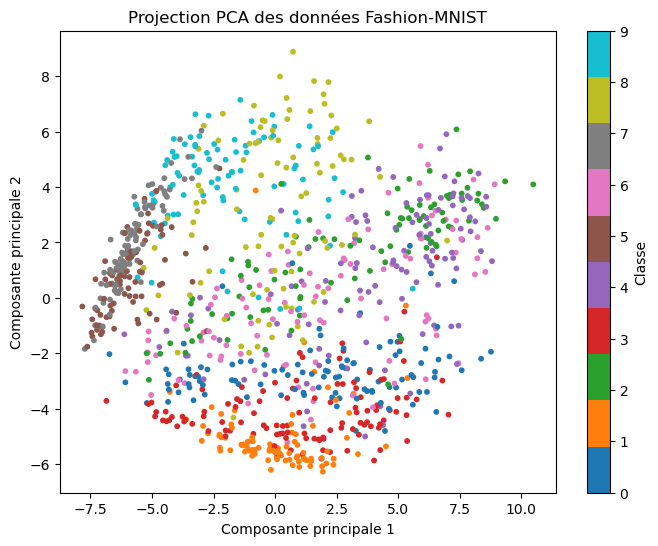

In [16]:
# --------------------------------------------------
# Visualisation des données après projection PCA
# --------------------------------------------------
# Chaque point représente une image.
# La couleur correspond à sa vraie classe.
# Cette visualisation permet d'observer si certaines
# classes semblent naturellement former des groupes.

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],      # première composante principale
    X_pca[:,1],      # deuxième composante principale
    c=y_unsup,       # couleur selon la classe réelle
    cmap="tab10",
    s=10
)

plt.colorbar(label="Classe")
plt.title("Projection PCA des données Fashion-MNIST")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")

plt.show()

In [43]:
# --------------------------------------------------
# Clustering K-Moyennes (bibliothèque iads)
# --------------------------------------------------

kmeans = clust.KMoyennes(K=10)

# apprentissage
Centres, Affect = kmeans.train(
    X_unsup,
    epsilon=0.01,
    iter_max=30,
    verbose=True
)

print("Nombre de clusters trouvés :", len(Affect))


Etapes de l'apprentissage (epsilon = 0.010 et iter_max = 30) :
	iteration n°1 : Inertie = 34993.5755	Difference = --
	iteration n°2 : Inertie = 33436.0630	Difference = 1557.5125
	iteration n°3 : Inertie = 33067.4349	Difference = 368.6281
	iteration n°4 : Inertie = 32938.3466	Difference = 129.0883
	iteration n°5 : Inertie = 32723.2701	Difference = 215.0765
	iteration n°6 : Inertie = 32254.1496	Difference = 469.1205
	iteration n°7 : Inertie = 31697.8332	Difference = 556.3164
	iteration n°8 : Inertie = 31473.9090	Difference = 223.9242
	iteration n°9 : Inertie = 31379.5143	Difference = 94.3947
	iteration n°10 : Inertie = 31318.2845	Difference = 61.2299
	iteration n°11 : Inertie = 31258.8820	Difference = 59.4025
	iteration n°12 : Inertie = 31225.0196	Difference = 33.8624
	iteration n°13 : Inertie = 31202.5313	Difference = 22.4882
	iteration n°14 : Inertie = 31196.7558	Difference = 5.7756
	iteration n°15 : Inertie = 31194.8849	Difference = 1.8709
	iteration n°16 : Inertie = 31194.8849	Diffe

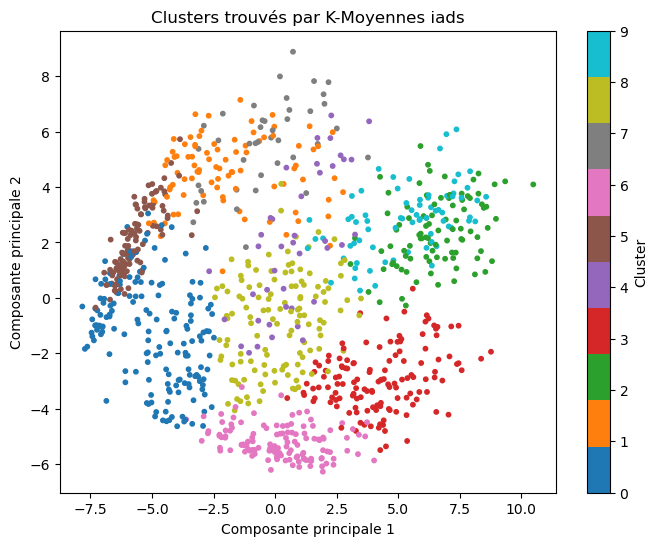

In [44]:
# --------------------------------------------------
# Visualisation des clusters trouvés par K-Moyennes iads
# --------------------------------------------------

# On transforme le dictionnaire Affect en tableau clusters
clusters = np.zeros(len(X_unsup), dtype=int)

for k in Affect:
    for i in Affect[k]:
        clusters[i] = k

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap="tab10",
    s=10
)

plt.colorbar(label="Cluster")
plt.title("Clusters trouvés par K-Moyennes iads")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")

plt.show()

In [45]:
# --------------------------------------------------
# Évaluation du clustering
# --------------------------------------------------

inertie = kmeans.inertie_globale(
    X_unsup,
    Affect
)

print("Inertie globale :", inertie)

print(
    "Indice de Xie-Beni :",
    clust.index_XieBeni(
        X_unsup,
        Centres,
        Affect
    )
)

Inertie globale : 31194.88487643286
Indice de Xie-Beni : 2.3031941718536038


In [46]:
# --------------------------------------------------
# Comparaison de plusieurs valeurs de k
# --------------------------------------------------

k_values = [5, 10, 15, 20]

inertias = []
xiebeni_scores = []

for k in k_values:

    print(f"\n===== k = {k} =====")

    kmeans = clust.KMoyennes(K=k)

    Centres, Affect = kmeans.train(
        X_unsup,
        epsilon=0.01,
        iter_max=30
    )

    inertie = kmeans.inertie_globale(
        X_unsup,
        Affect
    )

    xb = clust.index_XieBeni(
        X_unsup,
        Centres,
        Affect
    )

    inertias.append(inertie)
    xiebeni_scores.append(xb)

    print(f"k = {k} -> inertie = {inertie:.2f}")
    print(f"k = {k} -> Xie-Beni = {xb:.4f}")


===== k = 5 =====
k = 5 -> inertie = 38390.32
k = 5 -> Xie-Beni = 1.1068

===== k = 10 =====
k = 10 -> inertie = 31500.60
k = 10 -> Xie-Beni = 1.7113

===== k = 15 =====
k = 15 -> inertie = 28023.88
k = 15 -> Xie-Beni = 1.7358

===== k = 20 =====
k = 20 -> inertie = 26116.10
k = 20 -> Xie-Beni = 2.1087


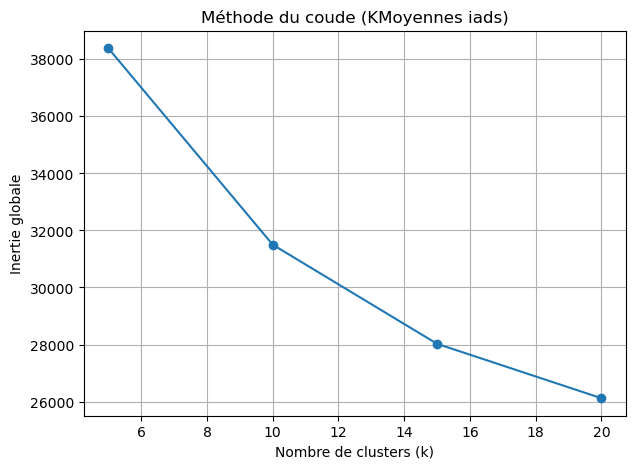

In [47]:
# --------------------------------------------------
# Méthode du coude
# --------------------------------------------------

plt.figure(figsize=(7,5))

plt.plot(
    k_values,
    inertias,
    marker="o"
)

plt.title("Méthode du coude (KMoyennes iads)")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie globale")

plt.grid(True)

plt.show()

In [48]:
# --------------------------------------------------
# Comparaison clusters / classes réelles
# --------------------------------------------------

# K=10 car Fashion-MNIST contient 10 classes
kmeans = clust.KMoyennes(K=10)

Centres, Affect = kmeans.train(
    X_unsup,
    epsilon=0.01,
    iter_max=30
)

# Pour chaque cluster, afficher la classe majoritaire
for cluster_id in Affect:

    indices = Affect[cluster_id]

    labels_cluster = y_unsup[indices]

    unique, counts = np.unique(
        labels_cluster,
        return_counts=True
    )

    classe_majoritaire = unique[np.argmax(counts)]

    print(
        f"Cluster {cluster_id} "
        f"-> classe majoritaire : {classe_majoritaire}"
    )

Cluster 0 -> classe majoritaire : 4
Cluster 1 -> classe majoritaire : 1
Cluster 2 -> classe majoritaire : 0
Cluster 3 -> classe majoritaire : 2
Cluster 4 -> classe majoritaire : 8
Cluster 5 -> classe majoritaire : 3
Cluster 6 -> classe majoritaire : 6
Cluster 7 -> classe majoritaire : 9
Cluster 8 -> classe majoritaire : 7
Cluster 9 -> classe majoritaire : 8


### Correspondance entre clusters et classes réelles

L'algorithme des K-moyennes est un algorithme d'apprentissage non supervisé : les labels des exemples ne sont pas utilisés lors de la construction des clusters. Cependant, il est possible d'évaluer qualitativement les résultats obtenus en comparant les clusters aux classes réelles du jeu de données.

L'analyse montre que plusieurs clusters sont dominés par une même classe, ce qui indique que l'algorithme parvient à regrouper des images présentant des caractéristiques similaires. Les clusters retrouvés reflètent donc partiellement la structure des données.

Néanmoins, la correspondance n'est pas parfaite. Certaines classes sont réparties sur plusieurs clusters, tandis que certains clusters contiennent des exemples provenant de différentes classes. Ce comportement est attendu, car l'objectif de K-moyennes est de regrouper les exemples selon leur proximité dans l'espace de représentation et non de reproduire exactement les labels réels.

Ces résultats montrent que l'algorithme capture une partie de l'organisation naturelle des données, mais qu'il existe des recouvrements entre certaines catégories de vêtements du jeu Fashion-MNIST.


In [49]:
# --------------------------------------------------
# Sous-échantillon pour le clustering hiérarchique
# --------------------------------------------------
# Le clustering hiérarchique est coûteux.
# On travaille donc sur un petit sous-ensemble.

n_hier = 100

X_hier = X_train[:n_hier]
y_hier = y_train[:n_hier]

print("X_hier :", X_hier.shape)
print("y_hier :", y_hier.shape)

X_hier : (100, 784)
y_hier : (100,)


In [50]:
# --------------------------------------------------
# Construction du clustering hiérarchique avec iads
# --------------------------------------------------
# On utilise la classification hiérarchique ascendante
# implémentée dans la bibliothèque iads.

linkage_choisi = clust.LinkageComplete()

Z = clust.CHA_algorithme(
    pd.DataFrame(X_hier),
    linkage_choisi,
    verbose=False
)

print("Nombre de fusions réalisées :", len(Z))

Nombre de fusions réalisées : 99


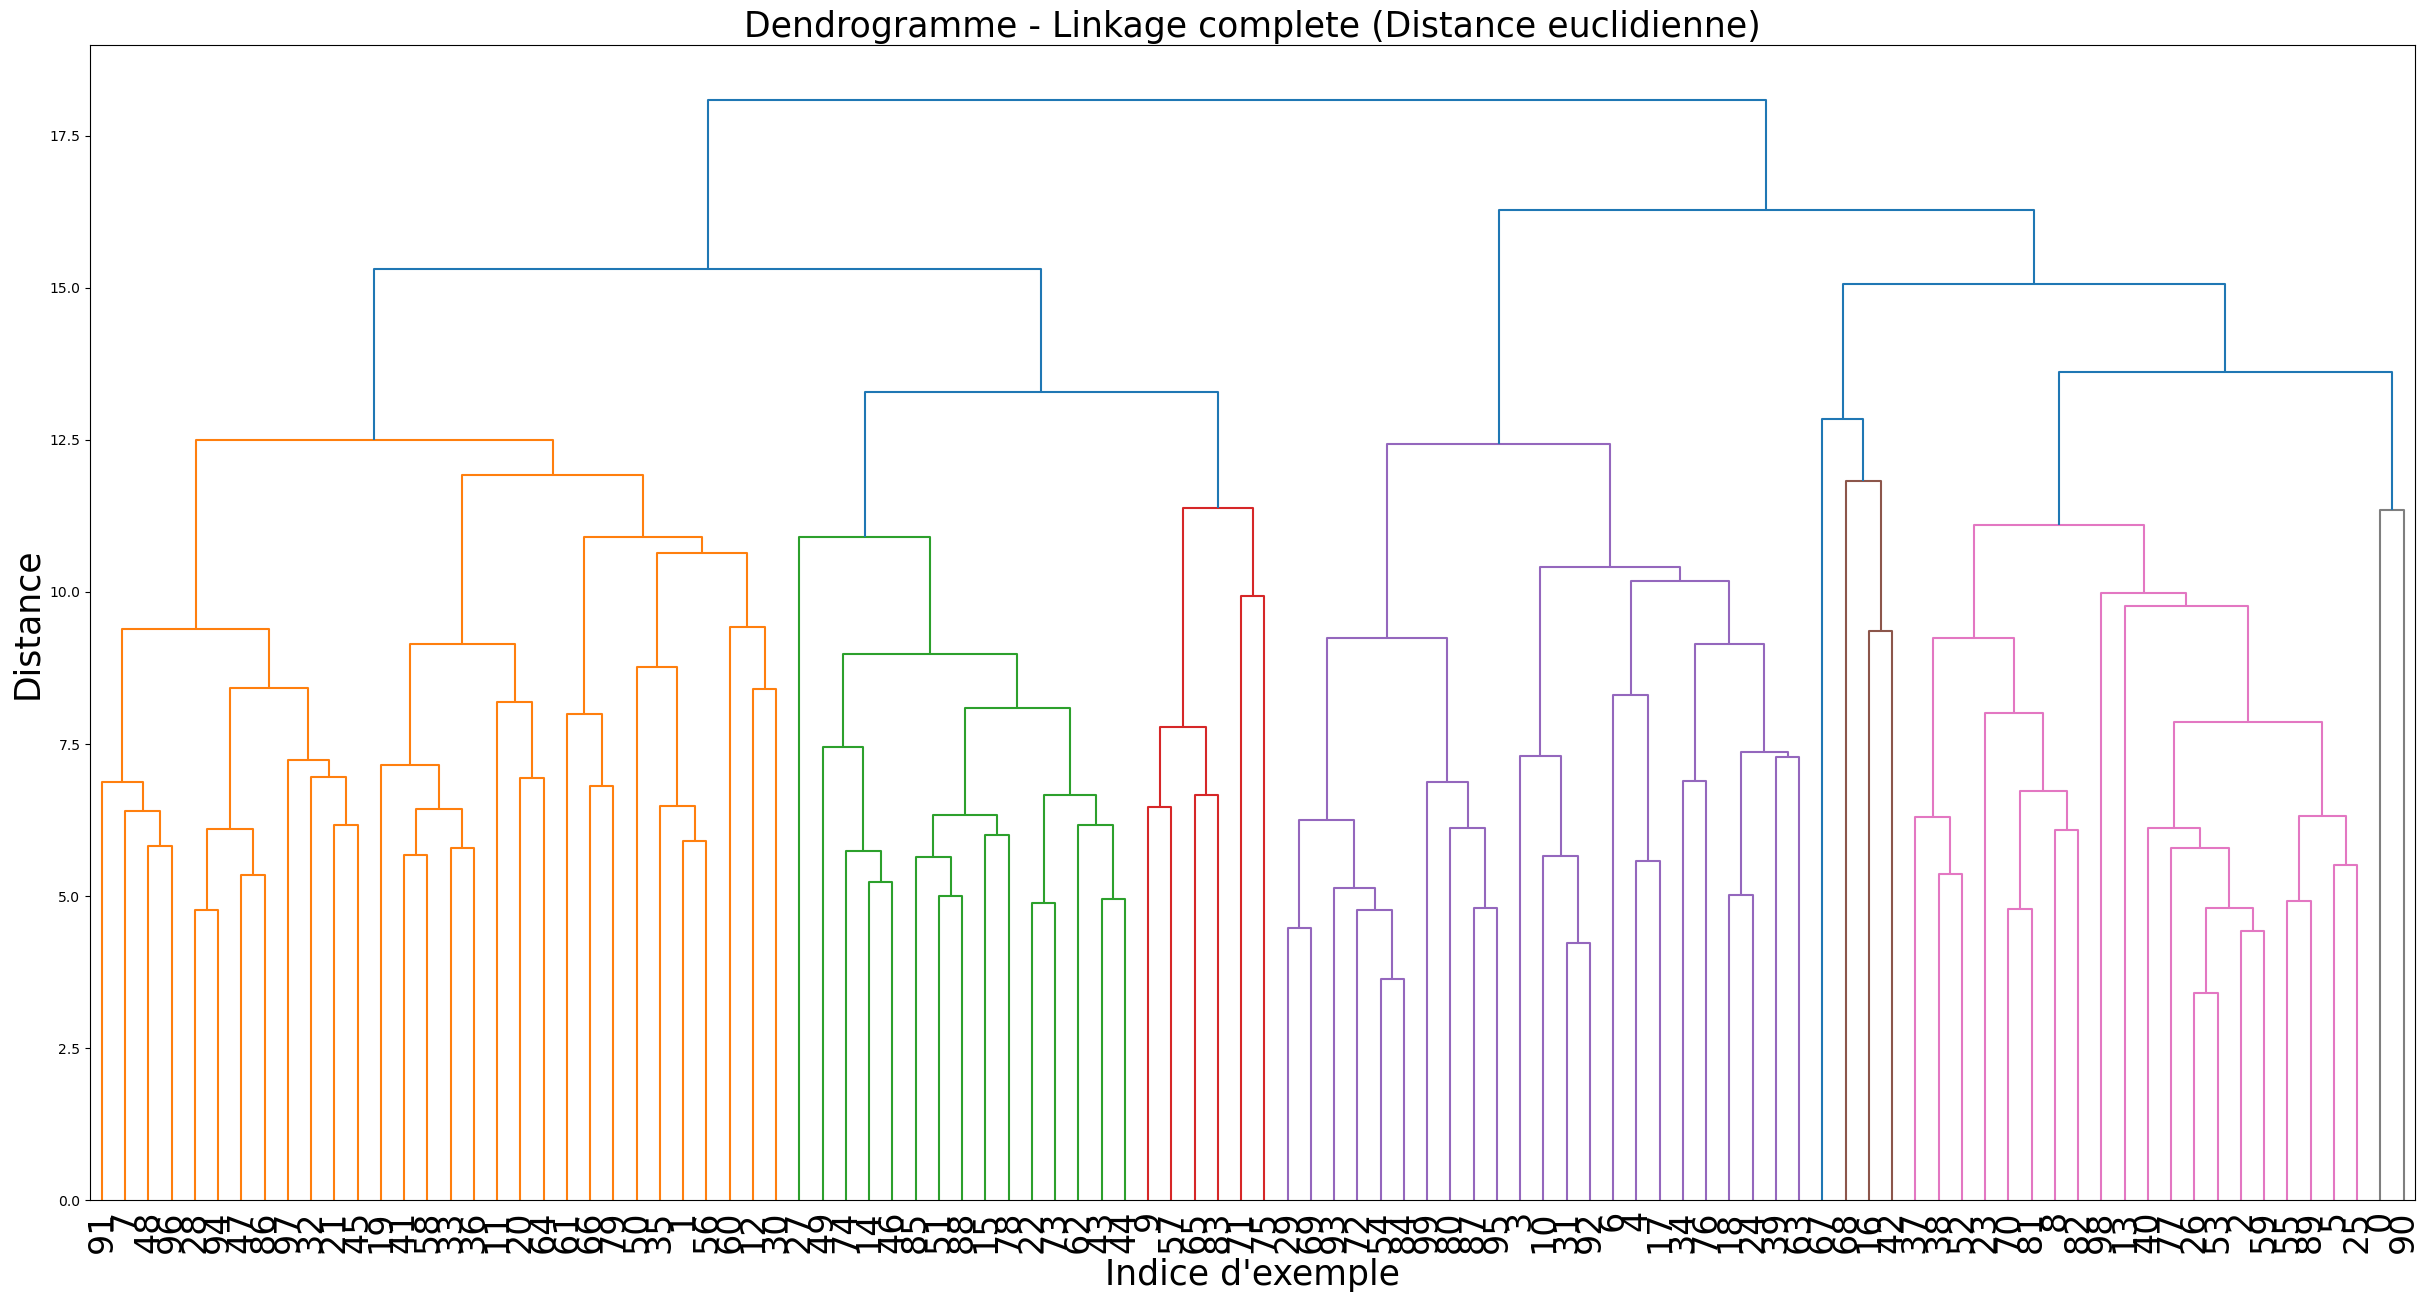

In [51]:
# --------------------------------------------------
# Affichage du dendrogramme
# --------------------------------------------------

clust.CHA_dendrogramme(
    Z,
    str(linkage_choisi)
)

### Analyse du clustering hiérarchique

Le dendrogramme met en évidence les regroupements successifs des données.

Certaines fusions apparaissent à faible distance, ce qui indique des exemples très proches. Les dernières fusions se produisent à des distances beaucoup plus élevées, suggérant l'existence de plusieurs groupes distincts dans les données.

Le clustering hiérarchique fournit une représentation visuelle intéressante de la structure des données mais son coût de calcul devient important lorsque le nombre d'exemples augmente.

Linkage utilisé : Linkage complete (Distance euclidienne)


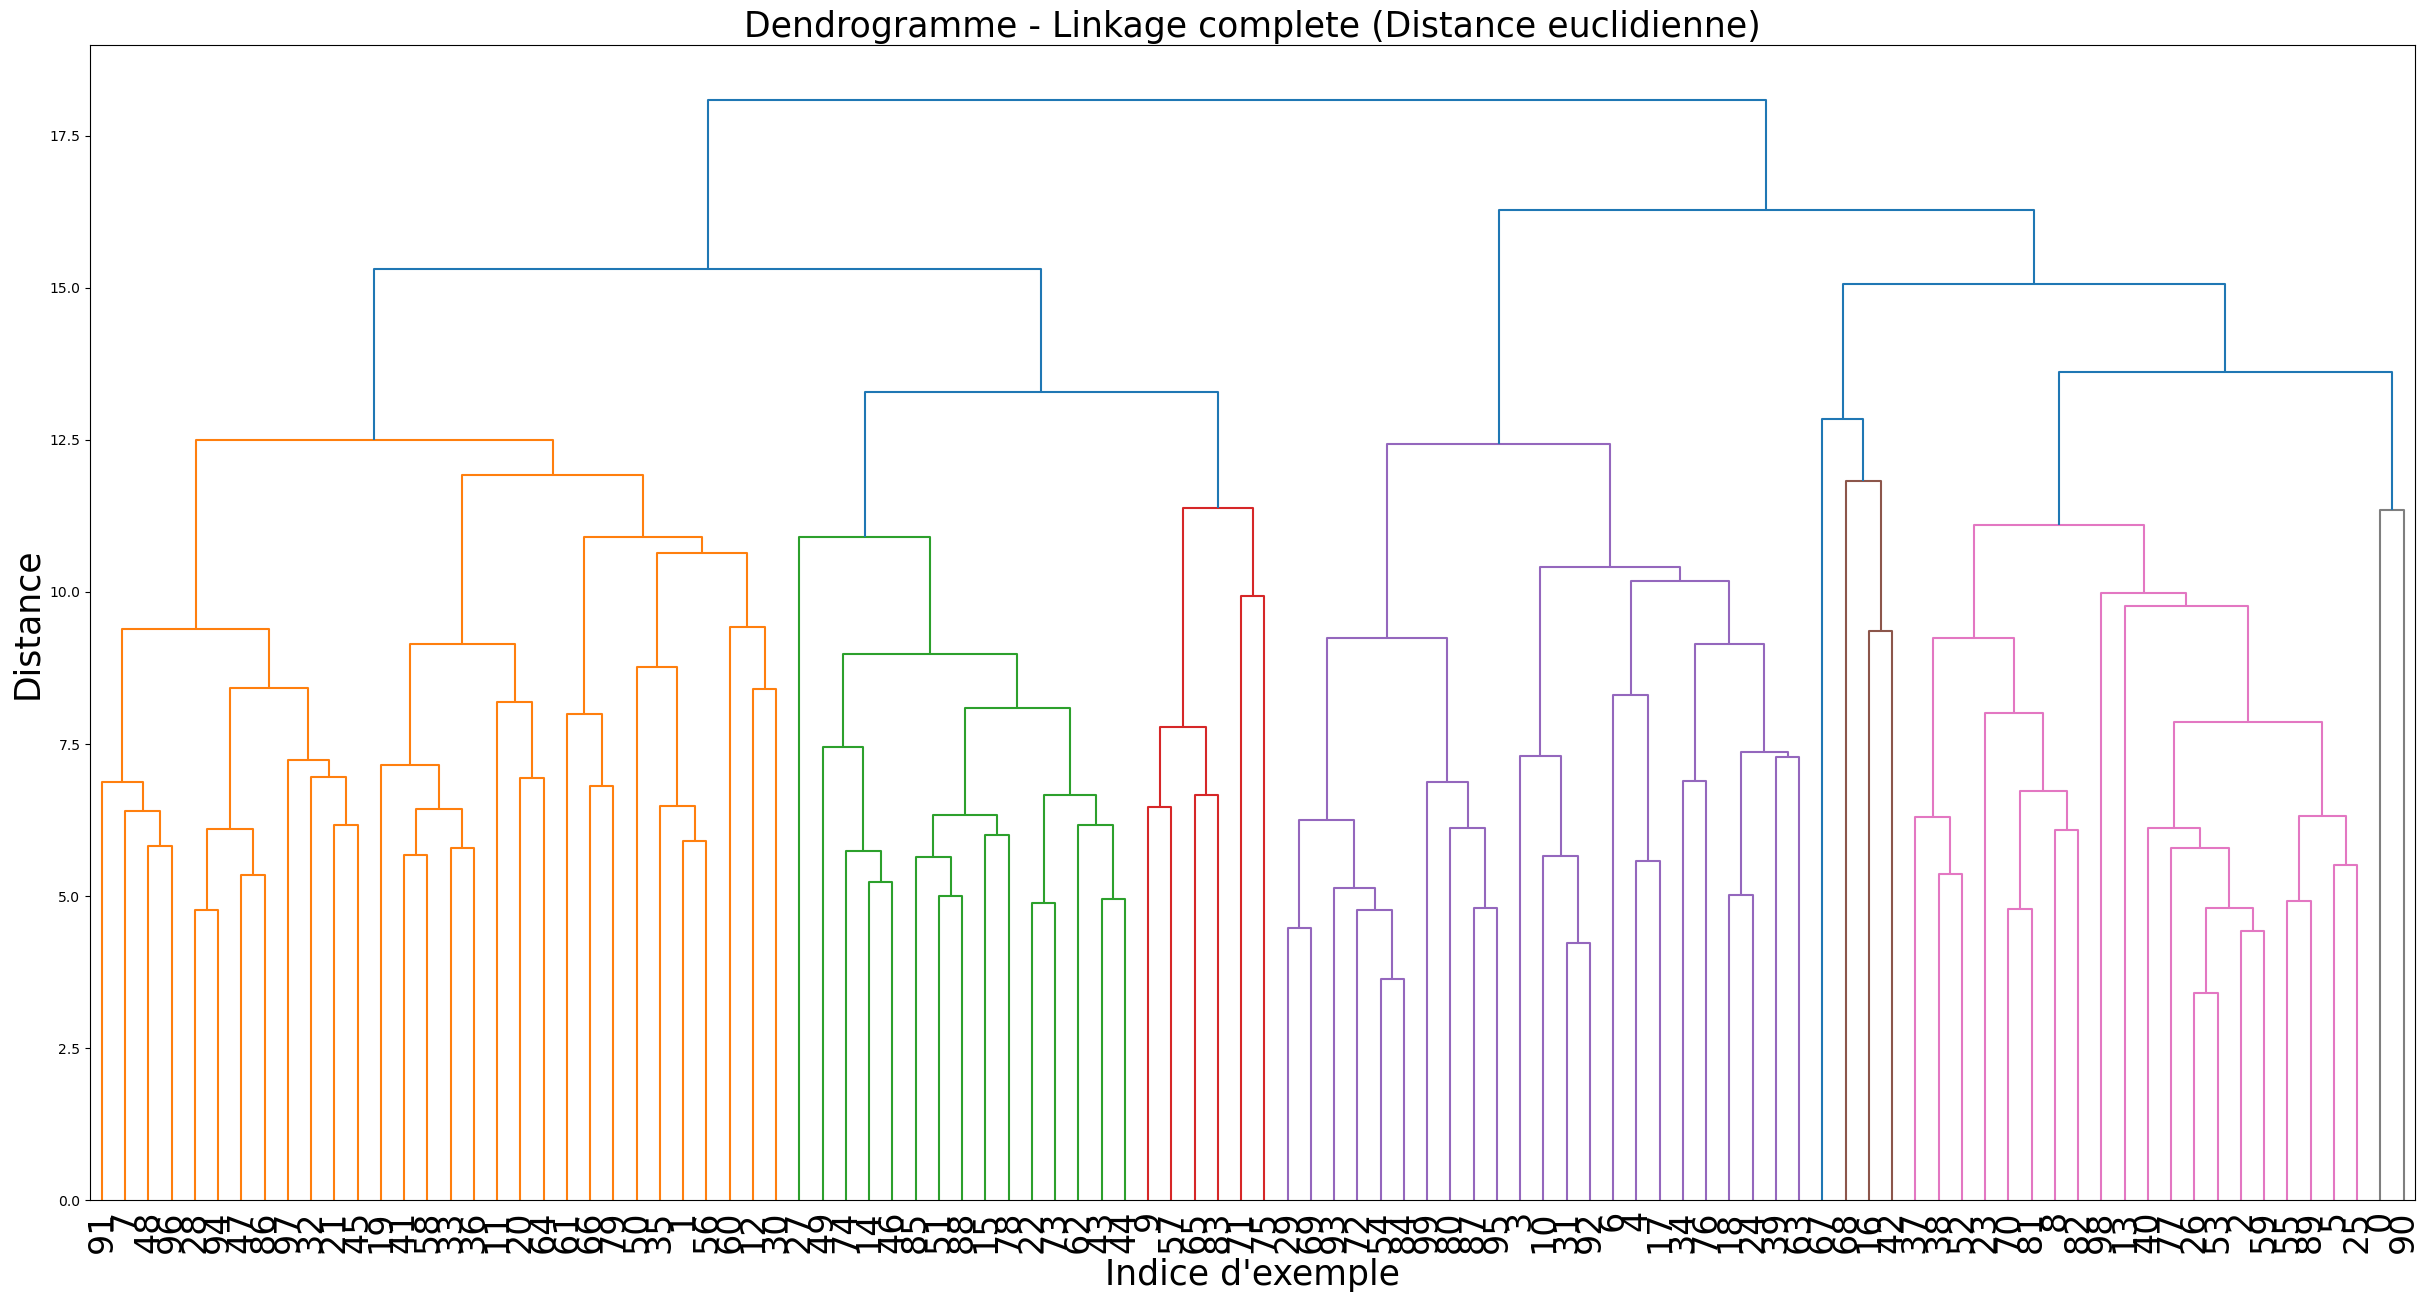

Linkage utilisé : Linkage simple (Distance euclidienne)


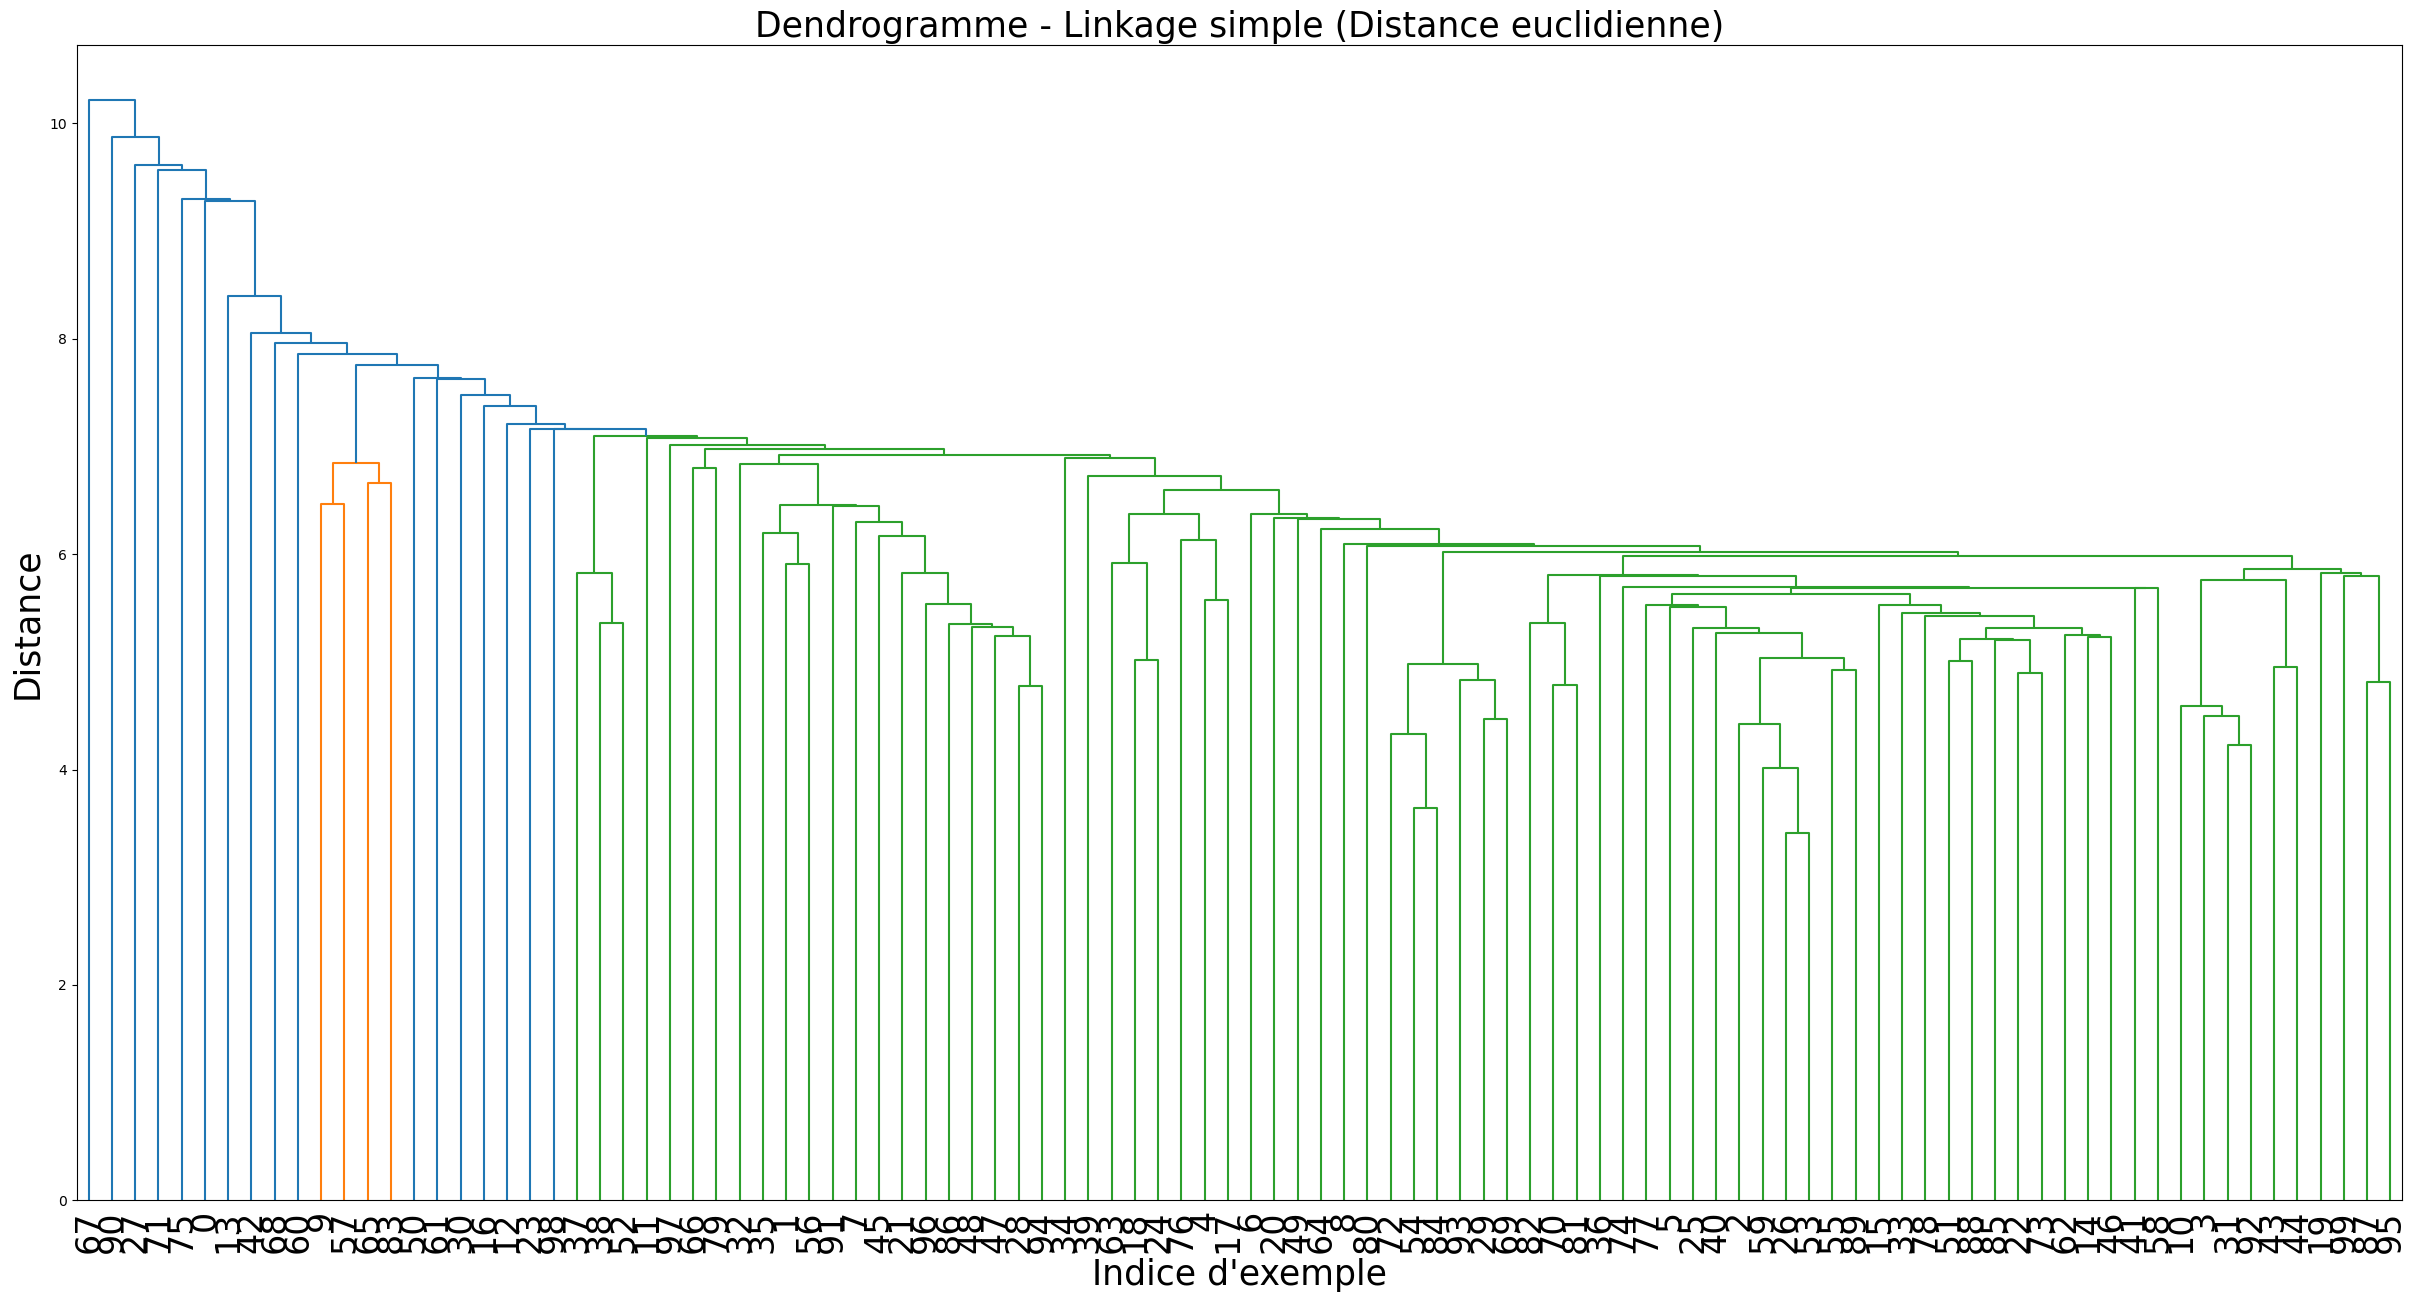

Linkage utilisé : Linkage average (Distance euclidienne)


In [ ]:
# --------------------------------------------------
# Comparaison de plusieurs linkages pour la CHA
# --------------------------------------------------

linkages = [
    clust.LinkageComplete(),
    clust.LinkageSimple(),
    clust.LinkageAverage()
]

for link in linkages:
    print("Linkage utilisé :", link)

    Z = clust.CHA_algorithme(
        pd.DataFrame(X_hier),
        link,
        verbose=False
    )

    clust.CHA_dendrogramme(
        Z,
        str(link)
    )

### Comparaison des linkages

Afin d'étudier l'influence du critère de fusion utilisé dans la classification hiérarchique ascendante, plusieurs linkages ont été testés : Complete, Simple et Average.

Les dendrogrammes obtenus montrent que le choix du linkage influence directement la structure de l'arbre hiérarchique. Les regroupements effectués ainsi que les distances de fusion ne sont pas identiques d'une méthode à l'autre.

Le linkage simple a tendance à relier rapidement des groupes proches, ce qui peut conduire à la formation de chaînes d'exemples. Le linkage complet favorise au contraire des groupes plus compacts en tenant compte de la plus grande distance entre les éléments de deux groupes. Le linkage moyen adopte un comportement intermédiaire en utilisant la distance moyenne entre les groupes.

Ces observations sont cohérentes avec les définitions étudiées en cours et dans le TME consacré à la classification hiérarchique ascendante.


### Conclusion

Dans cette étude, deux approches d'apprentissage non supervisé ont été appliquées au jeu de données Fashion-MNIST : l'algorithme des K-moyennes et la classification hiérarchique ascendante.

Les K-moyennes permettent de partitionner automatiquement les données en un nombre fixé de groupes et offrent des résultats facilement interprétables grâce à l'étude de l'inertie et à la méthode du coude. La comparaison avec les classes réelles montre que certains clusters correspondent à des catégories de vêtements bien identifiées.

La classification hiérarchique ascendante fournit quant à elle une représentation sous forme d'arbre qui met en évidence les relations de proximité entre les exemples. Les expériences réalisées avec différents linkages montrent que le choix du critère de fusion influence fortement l'organisation des groupes obtenus.

Ces résultats confirment que les méthodes non supervisées permettent de mettre en évidence une structure sous-jacente dans les données sans utiliser les labels pendant l'apprentissage.
